<a href="https://colab.research.google.com/github/k-zannnne/mliot-pyml-2026-hw/blob/main/week02/buoi2_DangNgocKhanhVan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [20]:
df=sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [21]:
cols=df.select_dtypes(include=np.number).columns
data={}
data['mean']=df[cols].mean()
data['median']=df[cols].median()
data['mode']=df[cols].apply(lambda x: x.mode()[0])
data['var']=df[cols].var()
data['std']=df[cols].std()
data['min']=df[cols].min()
data['max']=df[cols].max()
data['Q1']=df[cols].quantile(0.25)
data['Q3']=df[cols].quantile(0.75)
data['IQR']=data['Q3']-data['Q1']
summary=pd.DataFrame(data).T
print(summary)

        sepal_length  sepal_width  petal_length  petal_width
mean        5.843333     3.057333      3.758000     1.199333
median      5.800000     3.000000      4.350000     1.300000
mode        5.000000     3.000000      1.400000     0.200000
var         0.685694     0.189979      3.116278     0.581006
std         0.828066     0.435866      1.765298     0.762238
min         4.300000     2.000000      1.000000     0.100000
max         7.900000     4.400000      6.900000     2.500000
Q1          5.100000     2.800000      1.600000     0.300000
Q3          6.400000     3.300000      5.100000     1.800000
IQR         1.300000     0.500000      3.500000     1.500000


In [22]:
mean=df.groupby('species').mean()
print(mean)
std=df.groupby('species').std()
print(std)

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


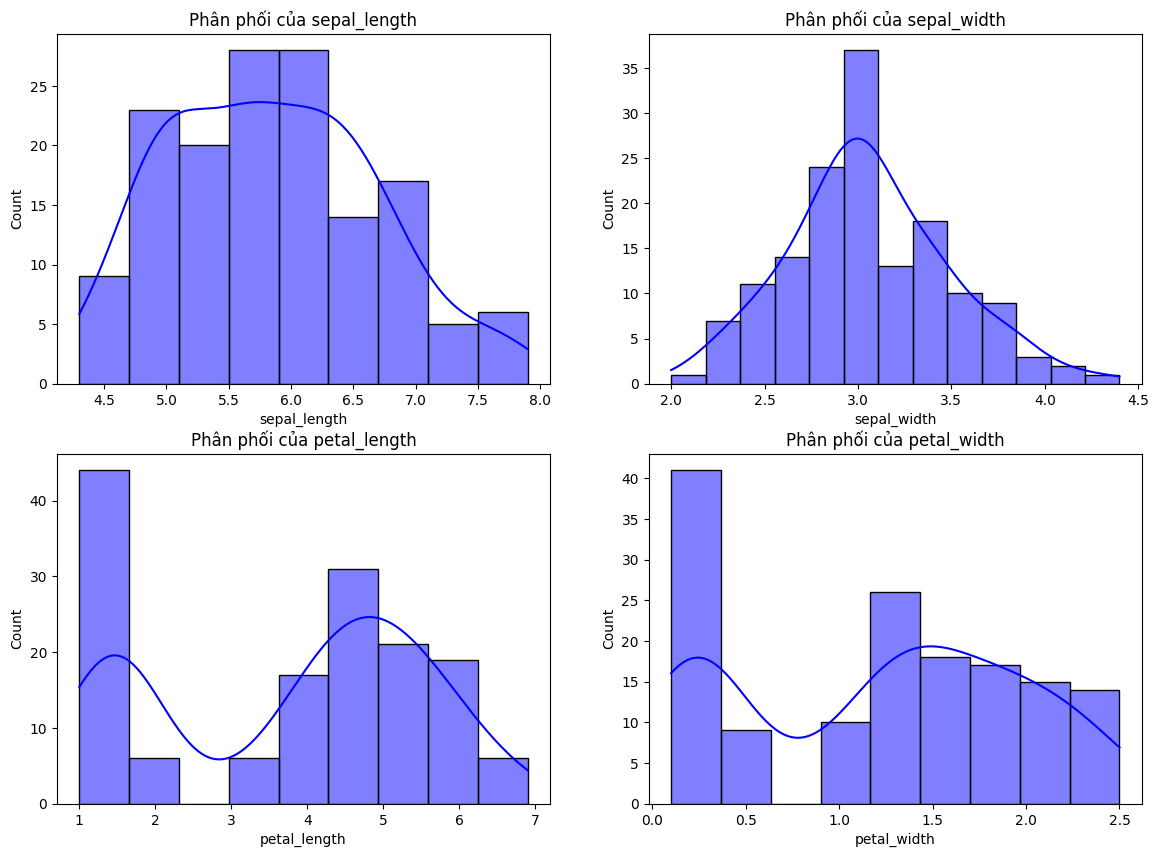

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="blue")
    axes[i].set_title(f"Phân phối của {col}")
plt.show()

- sepal_width phân phối đối xứng và đường cong khá giống phân phối chuẩn.
- sepal_length có xu hướng hơi lệch phải.
- petal_length và petal_width đường cong lên xuống tạo nhiều đỉnh.

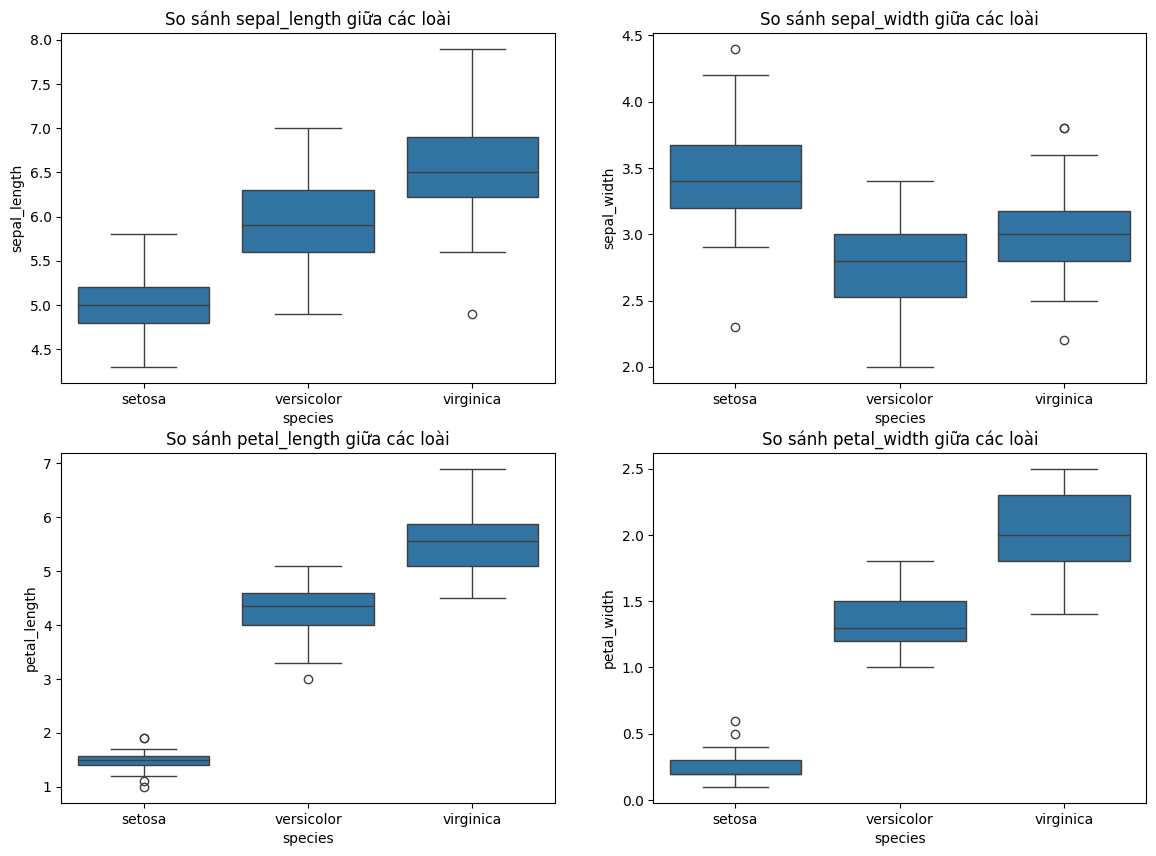

In [24]:
fig, axes=plt.subplots(2,2, figsize=(14,10))
axes=axes.flatten()
for i, col in enumerate(cols):
  sns.boxplot(x='species', y=col, data=df, ax=axes[i])
  axes[i].set_title(f"So sánh {col} giữa các loài")
plt.show()

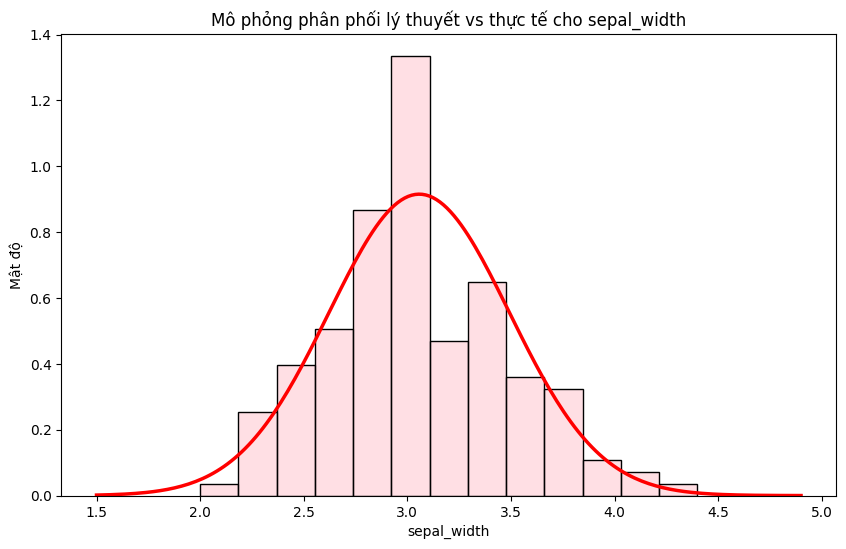

In [25]:
chosen = "sepal_width"
mu = df[chosen].mean()
sigma = df[chosen].std()
simulated_data = np.random.normal(mu, sigma, size=10000)
plt.figure(figsize=(10, 6))
sns.histplot(df[chosen], stat="density", alpha=0.5, color="pink")
x_axis = np.linspace(df[chosen].min() - 0.5, df[chosen].max() + 0.5, 200)
pdf_theoretical = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_axis - mu) / sigma) ** 2)
plt.plot(x_axis, pdf_theoretical, 'r-', linewidth=2.5, label="PDF Lý thuyết (Normal)")
plt.title(f"Mô phỏng phân phối lý thuyết vs thực tế cho {chosen}")
plt.xlabel(chosen)
plt.ylabel("Mật độ")
plt.show()

Biểu đồ cho thấy phân phối của biến sepal_width giống với hàm phân phối chuẩn đã được học.

In [26]:
cov=df[cols].cov()
cor=df[cols].corr()
print('Covariance: ', cov)
print('Correlation: ', cor)

Covariance:                sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006
Correlation:                sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


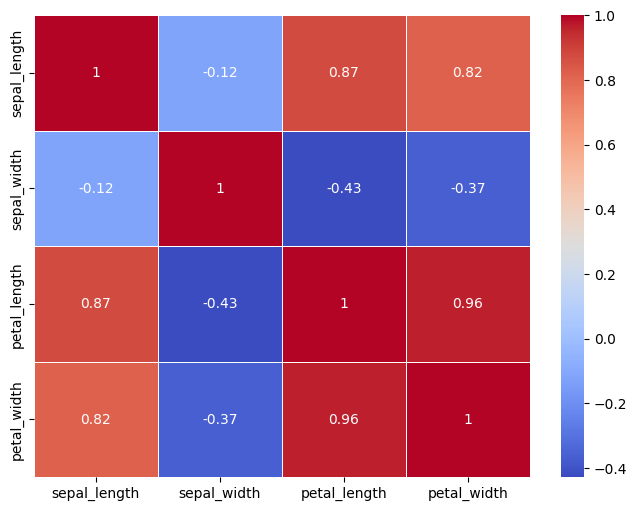

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(cor, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

- Cặp có tương quan tuyến tính mạnh nhất là petal_length và petal_width.
- Có dấu hiệu cộng đa tuyến và điều này làm nhiễu và mất độ tin cậy.

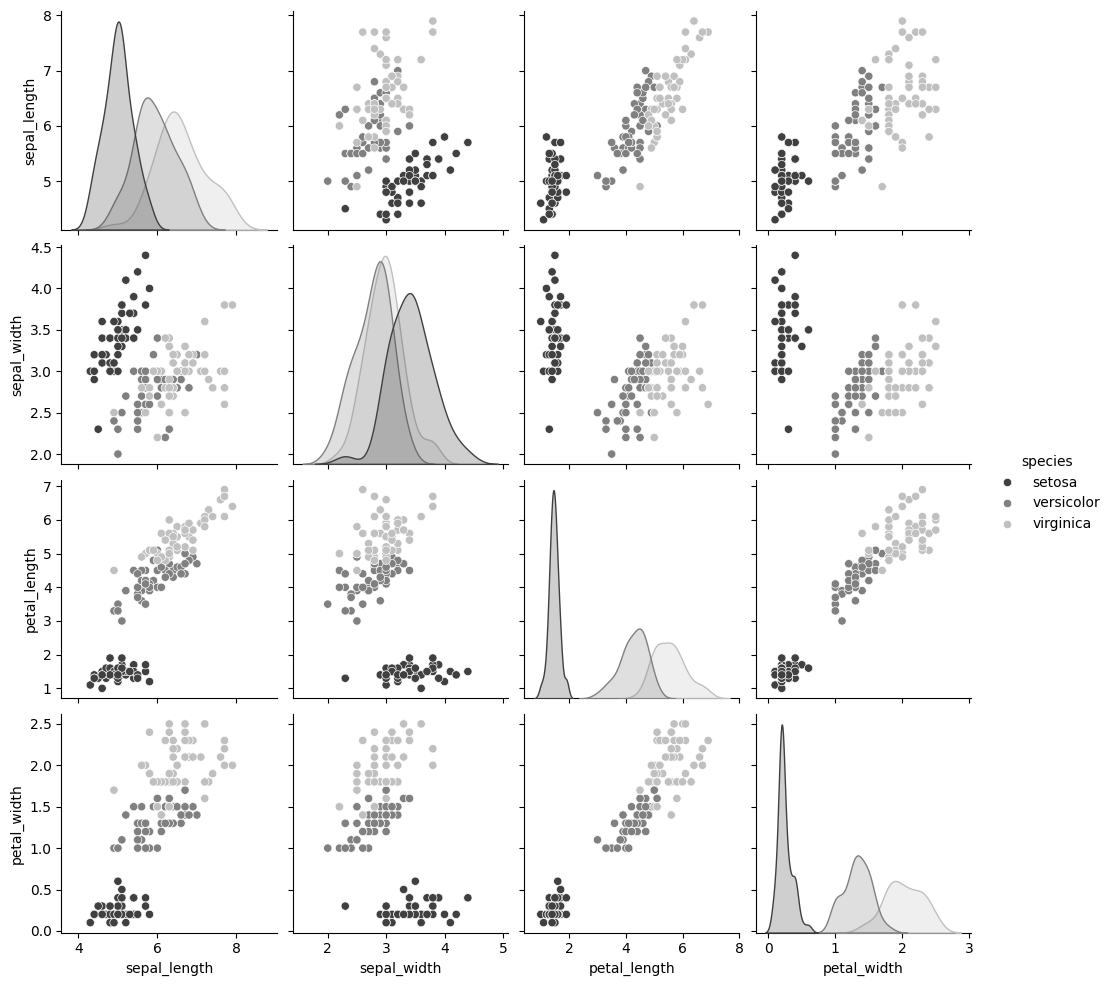

In [28]:
sns.pairplot(df, hue='species', palette='grey')
plt.show()

- petal_length và petal_width khá khơp với nhau điều này cho thấy cặp này tương quan tuyến tính mạnh. Ngược lại sepal_length và sepal_width tương quan tuyến tính yếu.
- Setosa tách thành cụm riêng biệt trong hầu hết các biểu đồ điều này cho thấy Setosa hoàn toàn độc lập và việc nhận diện cũng dễ dàng hơn.
- Versicolor và verginica nằm gần nhau, một số điểm nằm chồng lên nhau nhưng 2 loại này vẫn có tính riêng biệt nên có thể phân biệt được.

In [29]:
P_B=0.01
P_pos_givenB=0.99
P_pos_given_NB=0.05
P_pos=P_B*P_pos_givenB+(1-P_B)*P_pos_given_NB
P_B_given_pos=P_pos_givenB*P_B/P_pos
print (round( P_B_given_pos , 4))

0.1667


(0.0, 1.0)

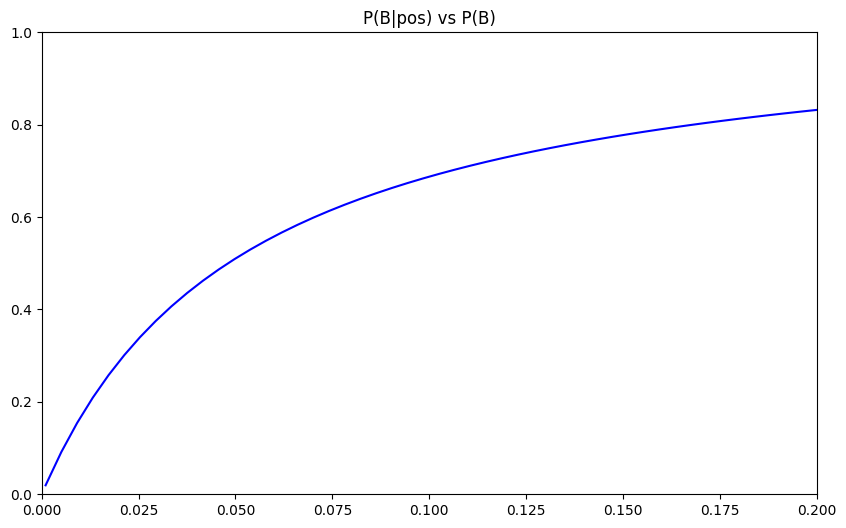

In [42]:
space=np.linspace(0.001, 0.2)
P_pos_space=space*P_pos_givenB+(1-space)*P_pos_given_NB
P_B_given_pos_space=P_pos_givenB*space/P_pos_space
plt.figure(figsize=(10, 6))
plt.plot(space, P_B_given_pos_space, color='blue')
plt.title('P(B|pos) vs P(B)')
plt.xlim(0, 0.2)
plt.ylim(0, 1.0)

Vì căn bệnh này hiếm P(B)=0.01 và xác xuất người khỏe 0.99. Dù tỉ lệ sai sót dương tính giả của máy rất thấp, số lượng ca bị báo sai trên thực tế sẽ lấn át hoàn toàn số ca dương tính thật.